# Фиксированные веса: auto_lover, alcohol, shopping

Веса из `config.FINAL_WEIGHTS`. Расчёт агрегированных признаков + Q5 + бинарный.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from pathlib import Path

from config import (
    TAGS_EXCEL_PATH, DATA_CSV_PART1, DATA_CSV_PART2, TARGET_COL,
    auto_lover, alcohol_features, shopping_features,
    FINAL_WEIGHTS, GROUPS_TO_BUILD, load_tag_lists,
)

## 1) Справочники групп тегов

Импортированы из `config.py`.

In [16]:
# Списки фичей импортированы из config.py
print(f'auto_lover: {len(auto_lover)} фичей')
print(f'alcohol_features: {len(alcohol_features)} фичей')
print(f'shopping_features: {len(shopping_features)} фичей')

## 2) Маппинг названий в `TAG_*` и словарь групп

`GROUP_TAGS` — это готовые группы тегов в кодах `TAG_*`.

In [17]:
tags_descriptions = pd.read_excel(TAGS_EXCEL_PATH, sheet_name='HT_list')
tag_lists = load_tag_lists(tags_descriptions)

GROUP_TAGS = {
    'alcohol': tag_lists['alcohol_features_list'],
    'shopping': tag_lists['shopping_features_list'],
    'auto_lover': tag_lists['auto_lover_list'],
}

print('Размеры групп TAG:')
for name, tags in GROUP_TAGS.items():
    print(f'{name}: {len(tags)}')

Размеры групп TAG:
alcohol: 16
shopping: 89
auto_lover: 67
not_auto_lover: 16


## 3) Загрузка выборки


In [18]:
part1 = pd.read_csv(DATA_CSV_PART1, encoding='cp1251', delimiter=',')
part2 = pd.read_csv(DATA_CSV_PART2, encoding='cp1251', delimiter=',')
casco_hashtags_full = pd.merge(part1, part2, on='POLICY_ZV', how='inner')
casco_hashtags_full[TARGET_COL] = casco_hashtags_full['CLAIMS_PART_DAM_COUNT'].astype(bool).astype(int)
casco_hashtags_full.set_index('POLICY_ZV', inplace=True)

casco_hashtags_full.drop(columns=['TAG_JOIN_IND'], inplace=True)
casco_hashtags_full['SUM'] = casco_hashtags_full.filter(like='TAG_').fillna(0).sum(axis=1)
casco_hashtags_full = casco_hashtags_full[casco_hashtags_full['SUM'] > 0]
print('casco_hashtags_full shape:', casco_hashtags_full.shape)

casco_hashtags_full shape: (51145, 1117)


## 4) Финальные веса из config.py

`FIXED_WEIGHTS_BY_GROUP` = `config.FINAL_WEIGHTS` — единый источник правды.

In [19]:
FIXED_WEIGHTS_BY_GROUP = FINAL_WEIGHTS

tag_map = tags_descriptions[['TAG', 'TAG_NAME fin SBS']].drop_duplicates()

for group_name, group_weights in FIXED_WEIGHTS_BY_GROUP.items():
    weights_table = (
        pd.Series(group_weights, name='integer_coef')
        .sort_values(ascending=False)
        .rename_axis('TAG')
        .reset_index()
        .merge(tag_map, on='TAG', how='left')
    )
    print()
    print(f'Фиксированные веса {group_name}:')
    print(weights_table[['TAG', 'TAG_NAME fin SBS', 'integer_coef']].to_string(index=False))


Фиксированные веса auto_lover:
      TAG                                  TAG_NAME fin SBS  integer_coef
TAG_10615                         Склонен к оплате парковки            10
TAG_20158           Склонен совершать покупки в АЗС Газпром             6
TAG_22019            Склонен к покупке запчастей в Exist.ru             5
TAG_20178       Склонен совершать покупки в Нефтьмагистраль             5
TAG_10616 Склонен к покупке товаров и услуг для нового авто             4
TAG_15296            Склонен пользоваться каршерингом редко             4
TAG_21998             Привычка покупать запчасти в Авторусь             4
TAG_10612                      Склонен к посещению автомоек             3
TAG_22560                       Склонен к покупке автомасел             3
TAG_11517                 Склонен покупать товары для охоты             2
TAG_15788       Склонен пользоваться каршерингом Делимобиль             2
TAG_10293                         Склонен оплачивать штрафы             2
TAG_27

## 5) Класс для fixed-weight группировки


In [20]:
class FixedWeightedEqualCountGrouper:
    def __init__(self, n_groups=5, min_groups=3, enforce_exact_equal=True):
        self.n_groups_requested_ = int(n_groups)
        self.min_groups = int(min_groups)
        self.enforce_exact_equal = bool(enforce_exact_equal)

        self.n_groups_effective_ = None
        self.n_groups_actual_ = None
        self.equal_group_size_ = None

        self.weights_all_ = None
        self.weights_active_ = None
        self.missing_tags_ = None
        self.group_stats_ = None

    def _nearest_divisor_not_above(self, n, target):
        divisors = [g for g in range(self.min_groups, n + 1) if n % g == 0]
        if not divisors:
            return None

        not_above = [g for g in divisors if g <= target]
        if not_above:
            return max(not_above)

        return min(divisors)

    def _assign_groups_strict(self, score, n_groups):
        s = pd.Series(score).astype(float)
        n = len(s)
        g = int(max(self.min_groups, min(int(n_groups), n)))

        idx_as_str = s.index.astype(str).to_numpy()
        order = np.lexsort((idx_as_str, s.to_numpy()))

        labels = np.empty(n, dtype=int)
        base = n // g
        rem = n % g

        start = 0
        for k in range(g):
            size = base + (1 if k < rem else 0)
            end = start + size
            labels[order[start:end]] = k
            start = end

        return pd.Series(labels, index=s.index, dtype=int)

    def fit(self, df, tag_weights, y, feature_name='feature'):
        if self.n_groups_requested_ < self.min_groups:
            raise ValueError(f'n_groups должен быть >= {self.min_groups}')

        weights = pd.Series(tag_weights, dtype=float)
        weights = weights[weights != 0]
        if weights.empty:
            raise ValueError('Передан пустой словарь весов (или все веса = 0).')

        self.weights_all_ = weights.sort_values(ascending=False)
        self.missing_tags_ = [t for t in self.weights_all_.index if t not in df.columns]
        active_tags = [t for t in self.weights_all_.index if t in df.columns]

        if not active_tags:
            raise ValueError(f"Для '{feature_name}' ни один TAG из весов не найден в датафрейме.")

        self.weights_active_ = self.weights_all_.loc[active_tags]

        X = df.reindex(columns=self.weights_active_.index, fill_value=0).fillna(0).astype(float)
        y = pd.Series(y, index=df.index).astype(float)
        score = X.dot(self.weights_active_)

        n_obs = len(score)
        eff = int(self.n_groups_requested_)
        if self.enforce_exact_equal and (n_obs % eff != 0):
            adjusted = self._nearest_divisor_not_above(n_obs, eff)
            if adjusted is None:
                raise ValueError('Не удалось подобрать делитель для строгих equal-count групп.')
            eff = int(adjusted)

        self.n_groups_effective_ = int(eff)

        groups = self._assign_groups_strict(score, self.n_groups_effective_)

        self.group_stats_ = (
            pd.DataFrame({'group': groups, 'target': y.values})
            .groupby('group', as_index=True)['target']
            .agg(['mean', 'count'])
            .sort_index()
            .rename(columns={'mean': 'claim_rate', 'count': 'objects'})
        )

        self.n_groups_actual_ = int(self.group_stats_.shape[0])
        self.equal_group_size_ = bool(self.group_stats_['objects'].nunique() == 1)
        return self

    def transform(self, df):
        if self.weights_active_ is None or self.n_groups_effective_ is None:
            raise ValueError('Сначала вызовите fit().')

        X = df.reindex(columns=self.weights_active_.index, fill_value=0).fillna(0).astype(float)
        score = X.dot(self.weights_active_)
        groups = self._assign_groups_strict(score, self.n_groups_effective_)
        return groups, score

## 6) Расчет агрегиронного tag по фиксированным весам + MinMax




In [21]:
BINARY_THRESHOLD = 0.5
N_QUANTILES = 5

def detect_monotonic_direction(rates, tol=1e-12):
    rates = np.asarray(rates, dtype=float)
    if rates.size <= 1:
        return 'flat', True, True
    diffs = np.diff(rates)
    non_decreasing = bool(np.all(diffs >= -tol))
    non_increasing = bool(np.all(diffs <= tol))
    if non_decreasing and non_increasing:
        direction = 'flat'
    elif non_decreasing:
        direction = 'up'
    elif non_increasing:
        direction = 'down'
    else:
        direction = None
    return direction, non_decreasing, non_increasing


ARTIFACTS_DIR = Path('artifacts')
CSV_DIR = ARTIFACTS_DIR / 'csv'
MODELS_DIR = ARTIFACTS_DIR / 'models'
for p in (CSV_DIR, MODELS_DIR):
    p.mkdir(parents=True, exist_ok=True)

OUTPUT_ALL_FEATURES_PATH = CSV_DIR / 'all_groups_agg_coef_with_binary.csv'
OUTPUT_ALL_Q5_PATH = CSV_DIR / 'all_groups_agg_coef_q5.csv'
OUTPUT_GROUP_SUMMARY_PATH = CSV_DIR / 'all_groups_agg_coef_summary.csv'
OUTPUT_WEIGHTS_REPORT_PATH = CSV_DIR / 'all_groups_coef_report.csv'

for group_name in GROUPS_TO_BUILD:
    if group_name not in GROUP_TAGS:
        raise ValueError(f'Группа {group_name} отсутствует в GROUP_TAGS')
    if group_name not in FIXED_WEIGHTS_BY_GROUP:
        raise ValueError(f'Для группы {group_name} нет весов в FIXED_WEIGHTS_BY_GROUP')

In [22]:
all_group_features = pd.DataFrame(index=casco_hashtags_full.index)
all_group_q5 = pd.DataFrame(index=casco_hashtags_full.index)
summary_rows = []
binary_analysis_by_group = {}
q5_analysis_by_group = {}
q5_direction_by_group = {}
weights_reports = []

tag_map = tags_descriptions[['TAG', 'TAG_NAME fin SBS']].drop_duplicates()

for group_name in GROUPS_TO_BUILD:
    selected_group_tags = list(GROUP_TAGS[group_name])
    if not selected_group_tags:
        raise ValueError(f'Группа {group_name} пустая')

    fixed_weights = FIXED_WEIGHTS_BY_GROUP[group_name]
    weights_full = pd.Series({tag: float(fixed_weights.get(tag, 0.0)) for tag in selected_group_tags}, dtype=float)

    X_group = (
        casco_hashtags_full
        .reindex(columns=selected_group_tags, fill_value=0)
        .fillna(0)
        .astype(float)
    )

    score_raw = X_group.mul(weights_full, axis=1).sum(axis=1)
    score_minmax = MinMaxScaler().fit_transform(score_raw.values.reshape(-1, 1)).flatten()
    score_binary = (score_minmax >= BINARY_THRESHOLD).astype(int)

    score_col = f'{group_name}_agg_coef'
    binary_col = f'{group_name}_agg_coef_bin'
    q5_col = f'{group_name}_agg_coef_q{N_QUANTILES}'

    all_group_features[score_col] = score_minmax.astype(float)
    all_group_features[binary_col] = score_binary.astype(int)

    score_series = pd.Series(score_minmax, index=casco_hashtags_full.index)
    if len(score_series) < N_QUANTILES:
        raise ValueError(f'Недостаточно объектов для q{N_QUANTILES}: {len(score_series)}')
    score_rank = score_series.rank(method='first')
    q5_groups = pd.qcut(score_rank, q=N_QUANTILES, labels=False).astype(int).to_numpy()
    all_group_q5[q5_col] = q5_groups

    score_table = pd.DataFrame(index=casco_hashtags_full.index)
    score_table[score_col] = score_minmax.astype(float)
    score_table[binary_col] = score_binary.astype(int)
    score_table[q5_col] = q5_groups
    score_table[TARGET_COL] = casco_hashtags_full[TARGET_COL].astype(float)

    binary_analysis = (
        score_table.groupby(binary_col, as_index=True)[TARGET_COL]
        .agg(['mean', 'count'])
        .rename(columns={'mean': 'claim_rate', 'count': 'objects'})
        .sort_index()
    )
    binary_analysis_by_group[group_name] = binary_analysis

    q5_analysis = (
        score_table.groupby(q5_col, as_index=True)
        .agg(
            mean_score_minmax=(score_col, 'mean'),
            claim_rate=(TARGET_COL, 'mean'),
            objects=(TARGET_COL, 'count')
        )
        .sort_index()
    )
    q5_analysis_by_group[group_name] = q5_analysis

    direction_q5, mono_up_q5, mono_down_q5 = detect_monotonic_direction(q5_analysis['claim_rate'].values)
    q5_direction_by_group[group_name] = {
        'direction': direction_q5,
        'non_decreasing': mono_up_q5,
        'non_increasing': mono_down_q5,
    }

    claim_rate_0 = float(binary_analysis.loc[0, 'claim_rate']) if 0 in binary_analysis.index else np.nan
    claim_rate_1 = float(binary_analysis.loc[1, 'claim_rate']) if 1 in binary_analysis.index else np.nan
    objects_0 = int(binary_analysis.loc[0, 'objects']) if 0 in binary_analysis.index else 0
    objects_1 = int(binary_analysis.loc[1, 'objects']) if 1 in binary_analysis.index else 0

    summary_rows.append({
        'group': group_name,
        'total_tags_in_group': int(len(selected_group_tags)),
        'nonzero_coef': int((weights_full != 0).sum()),
        'zero_coef': int((weights_full == 0).sum()),
        'objects_bin_0': objects_0,
        'objects_bin_1': objects_1,
        'claim_rate_bin_0': claim_rate_0,
        'claim_rate_bin_1': claim_rate_1,
        'claim_rate_lift_1_vs_0': float(claim_rate_1 - claim_rate_0) if np.isfinite(claim_rate_0) and np.isfinite(claim_rate_1) else np.nan,
        'q5_direction': direction_q5,
        'q5_non_decreasing': bool(mono_up_q5),
        'q5_non_increasing': bool(mono_down_q5),
    })

    weights_report = (
        weights_full
        .rename('integer_coef')
        .rename_axis('TAG')
        .reset_index()
    )
    weights_report['group'] = group_name
    weights_report['is_nonzero_coef'] = weights_report['integer_coef'] != 0
    weights_reports.append(weights_report)

group_summary_df = pd.DataFrame(summary_rows).sort_values('group').reset_index(drop=True)
weights_report_all = pd.concat(weights_reports, ignore_index=True)
weights_report_all = weights_report_all.merge(tag_map, on='TAG', how='left')
weights_report_nonzero = (
    weights_report_all[weights_report_all['is_nonzero_coef']]
    .sort_values(['group', 'integer_coef'], ascending=[True, False])
    .reset_index(drop=True)
)

all_group_features.to_csv(OUTPUT_ALL_FEATURES_PATH, index=True, encoding='utf-8-sig')
all_group_q5.to_csv(OUTPUT_ALL_Q5_PATH, index=True, encoding='utf-8-sig')
group_summary_df.to_csv(OUTPUT_GROUP_SUMMARY_PATH, index=False, encoding='utf-8-sig')
weights_report_all.to_csv(OUTPUT_WEIGHTS_REPORT_PATH, index=False, encoding='utf-8-sig')

print(f'Сохранен файл с фичами (8 колонок: continuous + binary): {OUTPUT_ALL_FEATURES_PATH}')
print(f'Сохранен файл с квантильными группами q{N_QUANTILES}: {OUTPUT_ALL_Q5_PATH}')
print(f'Сохранен файл со сводкой по группам: {OUTPUT_GROUP_SUMMARY_PATH}')
print(f'Сохранен файл с весами всех групп: {OUTPUT_WEIGHTS_REPORT_PATH}')

Сохранен файл с фичами (8 колонок: continuous + binary): artifacts\csv\all_groups_agg_coef_with_binary.csv
Сохранен файл с квантильными группами q5: artifacts\csv\all_groups_agg_coef_q5.csv
Сохранен файл со сводкой по группам: artifacts\csv\all_groups_agg_coef_summary.csv
Сохранен файл с весами всех групп: artifacts\csv\all_groups_coef_report.csv


In [23]:
print()
print('Сводка по группам (2 колонки на группу: continuous + binary):')
print(group_summary_df.to_string(index=False))
print()
print(f'Порог бинаризации: {BINARY_THRESHOLD}')
print(f'Количество квантильных групп: {N_QUANTILES}')

print()
print('Новые признаки (первые 20 строк):')
print(all_group_features.head(20).to_string())

print()
print('Q5-группы (первые 20 строк):')
print(all_group_q5.head(20).to_string())


Сводка по группам (2 колонки на группу: continuous + binary):
         group  total_tags_in_group  nonzero_coef  zero_coef  objects_bin_0  objects_bin_1  claim_rate_bin_0  claim_rate_bin_1  claim_rate_lift_1_vs_0 q5_direction  q5_non_decreasing  q5_non_increasing
       alcohol                   16             5         11          51094             51          0.204368          0.352941                0.148573         None              False              False
    auto_lover                   67            17         50          49768           1377          0.202500          0.277415                0.074915         None              False              False
not_auto_lover                   16             7          9          50933            212          0.204268          0.264151                0.059883         None              False              False
      shopping                   89            40         49          50354            791          0.203420          0.274336   

In [24]:
for group_name in GROUPS_TO_BUILD:
    print()
    print(f"Анализ бинарного признака для группы '{group_name}':")
    print(binary_analysis_by_group[group_name])

    print(f"Q{N_QUANTILES}-анализ для группы '{group_name}':")
    print(q5_analysis_by_group[group_name])

    trend = q5_direction_by_group[group_name]
    print(
        f"Направление q{N_QUANTILES}: {trend['direction']}, "
        f"неубывающий={trend['non_decreasing']}, "
        f"невозрастающий={trend['non_increasing']}"
    )


Анализ бинарного признака для группы 'auto_lover':
                         claim_rate  objects
auto_lover_agg_coef_bin                     
0                          0.202500    49768
1                          0.277415     1377
Q5-анализ для группы 'auto_lover':
                        mean_score_minmax  claim_rate  objects
auto_lover_agg_coef_q5                                        
0                                0.000000    0.190830    10229
1                                0.006256    0.178414    10229
2                                0.089616    0.196696    10229
3                                0.213088    0.217030    10229
4                                0.395318    0.239613    10229
Направление q5: None, неубывающий=False, невозрастающий=False

Анализ бинарного признака для группы 'not_auto_lover':
                             claim_rate  objects
not_auto_lover_agg_coef_bin                     
0                              0.204268    50933
1                          

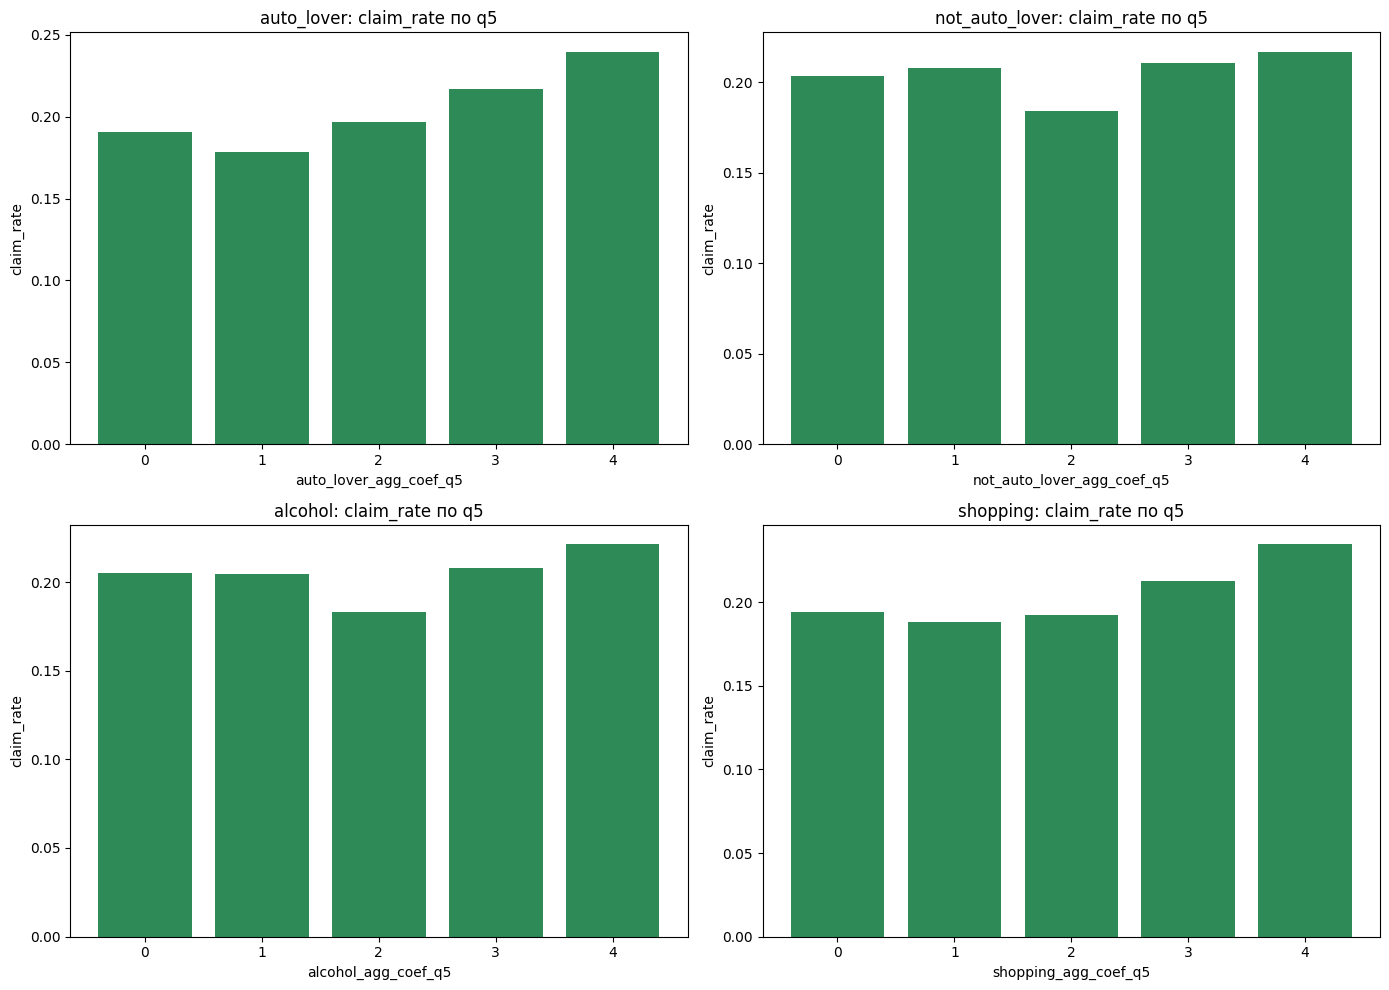

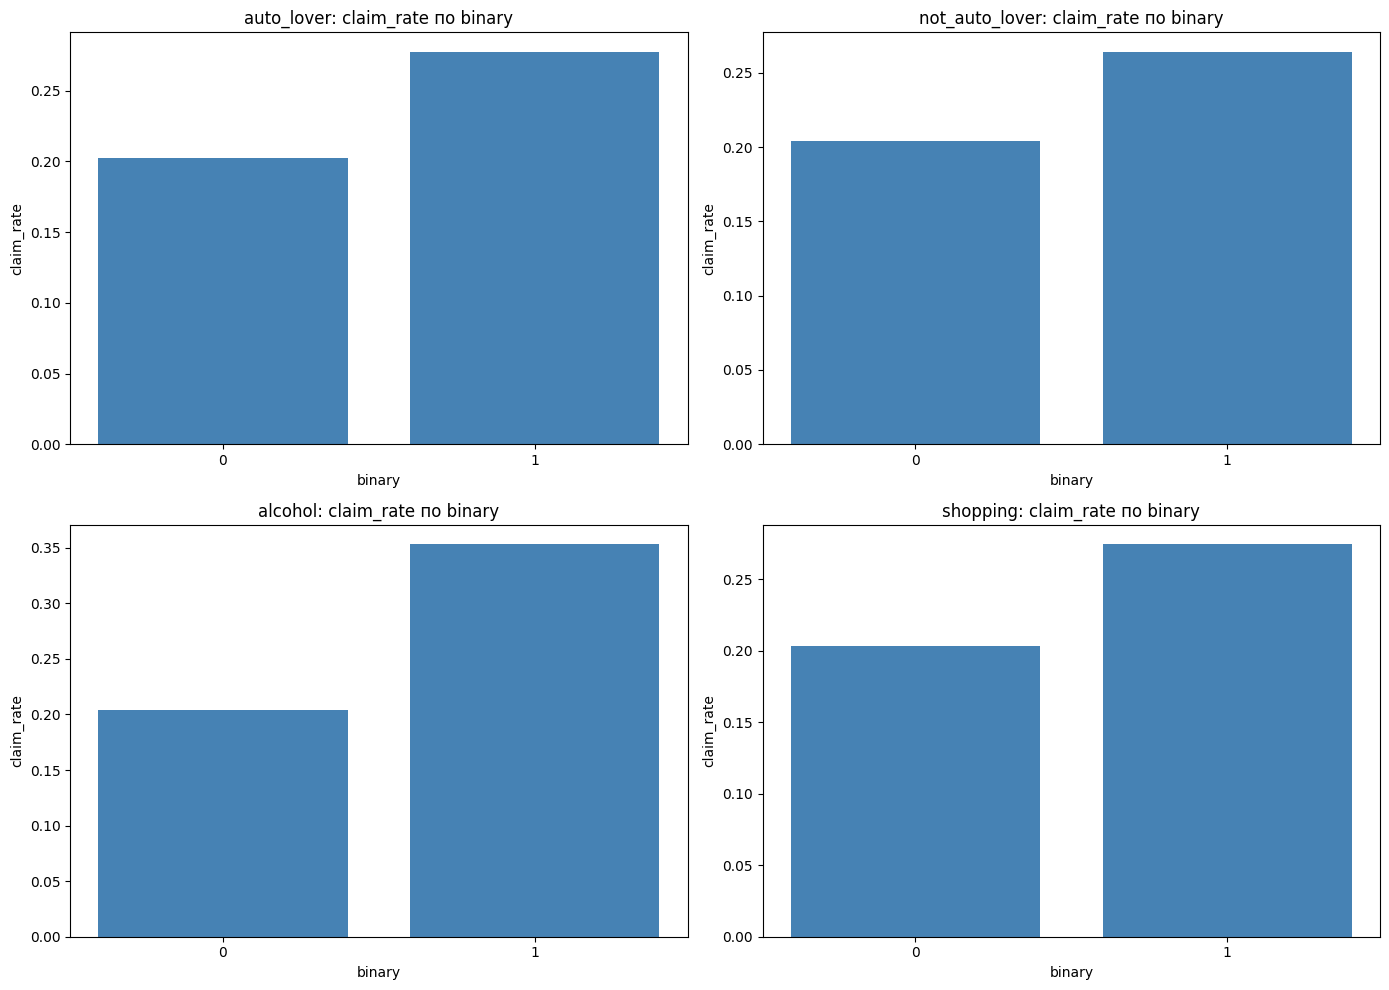

In [25]:
# Графики 1: частота аварий по квантильным группам для каждой группы
n_groups = len(GROUPS_TO_BUILD)
fig, axes = plt.subplots(1, n_groups, figsize=(6 * n_groups, 5))
if n_groups == 1:
    axes = [axes]

for ax, group_name in zip(axes, GROUPS_TO_BUILD):
    q5_analysis = q5_analysis_by_group[group_name]
    ax.bar(q5_analysis.index.astype(str), q5_analysis['claim_rate'], color='seagreen')
    ax.set_title(f'{group_name}: claim_rate по q{N_QUANTILES}')
    ax.set_xlabel(f'{group_name}_agg_coef_q{N_QUANTILES}')
    ax.set_ylabel('claim_rate')

plt.tight_layout()
plt.show()

# Графики 2: частота аварий по binary для каждой группы
fig, axes = plt.subplots(1, n_groups, figsize=(6 * n_groups, 5))
if n_groups == 1:
    axes = [axes]

for ax, group_name in zip(axes, GROUPS_TO_BUILD):
    binary_analysis = binary_analysis_by_group[group_name]
    ax.bar(binary_analysis.index.astype(str), binary_analysis['claim_rate'], color='steelblue')
    ax.set_title(f'{group_name}: claim_rate по binary')
    ax.set_xlabel('binary')
    ax.set_ylabel('claim_rate')

plt.tight_layout()
plt.show()

In [26]:
print()
print('Ненулевые веса по группам:')
for group_name in GROUPS_TO_BUILD:
    print()
    print(f'Группа: {group_name}')
    show_df = weights_report_nonzero[weights_report_nonzero['group'] == group_name]
    print(show_df[['TAG', 'TAG_NAME fin SBS', 'integer_coef']].to_string(index=False))


Ненулевые веса по группам:

Группа: auto_lover
      TAG                                  TAG_NAME fin SBS  integer_coef
TAG_10615                         Склонен к оплате парковки          10.0
TAG_20158           Склонен совершать покупки в АЗС Газпром           6.0
TAG_20178       Склонен совершать покупки в Нефтьмагистраль           5.0
TAG_22019            Склонен к покупке запчастей в Exist.ru           5.0
TAG_10616 Склонен к покупке товаров и услуг для нового авто           4.0
TAG_15296            Склонен пользоваться каршерингом редко           4.0
TAG_21998             Привычка покупать запчасти в Авторусь           4.0
TAG_10612                      Склонен к посещению автомоек           3.0
TAG_22560                       Склонен к покупке автомасел           3.0
TAG_10293                         Склонен оплачивать штрафы           2.0
TAG_11517                 Склонен покупать товары для охоты           2.0
TAG_15785      Склонен пользоваться каршерингом ЯндексДрайв     

In [27]:
print()
print('Все веса (включая 0) сохранены в:')
print(OUTPUT_WEIGHTS_REPORT_PATH)


Все веса (включая 0) сохранены в:
artifacts\csv\all_groups_coef_report.csv


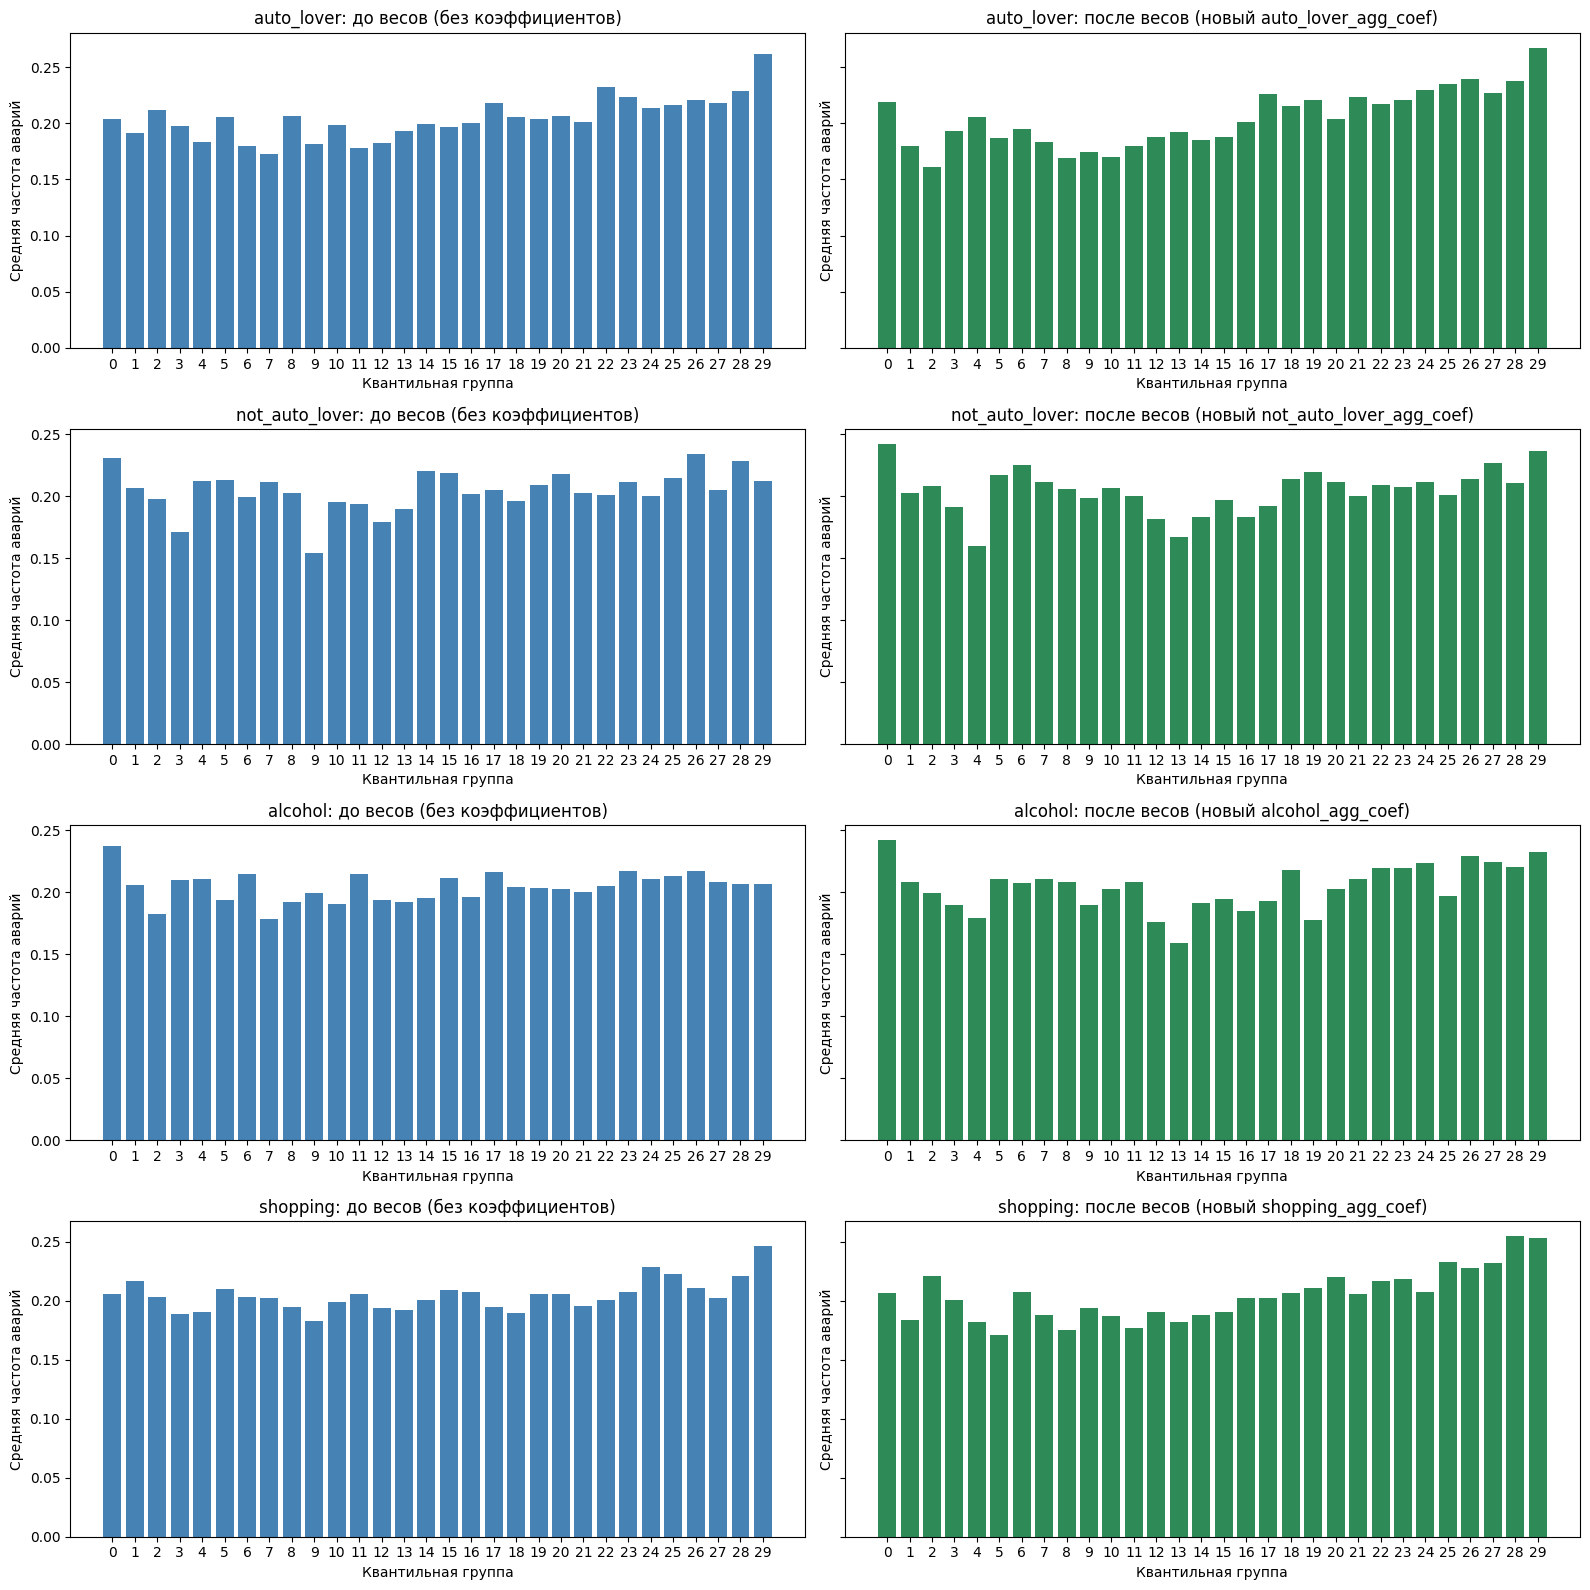

In [28]:
# --- Сравнение: до весов vs после весов для каждой группы ---
COMPARE_Q = 30

fig, axes = plt.subplots(len(GROUPS_TO_BUILD), 2, figsize=(16, 4 * len(GROUPS_TO_BUILD)), sharey='row')
if len(GROUPS_TO_BUILD) == 1:
    axes = [axes]

for i, group_name in enumerate(GROUPS_TO_BUILD):
    selected_group_tags = list(GROUP_TAGS[group_name])
    X_group = (
        casco_hashtags_full
        .reindex(columns=selected_group_tags, fill_value=0)
        .fillna(0)
        .astype(float)
    )

    # До весов: простой суммарный score
    score_before_raw = X_group.sum(axis=1)
    score_before = MinMaxScaler().fit_transform(score_before_raw.values.reshape(-1, 1)).flatten()

    # После весов: score с фиксированными коэффициентами
    fixed_weights = FIXED_WEIGHTS_BY_GROUP[group_name]
    weights_full = pd.Series({tag: float(fixed_weights.get(tag, 0.0)) for tag in selected_group_tags}, dtype=float)
    score_after_raw = X_group.mul(weights_full, axis=1).sum(axis=1)
    score_after = MinMaxScaler().fit_transform(score_after_raw.values.reshape(-1, 1)).flatten()

    plot_df = pd.DataFrame({
        'score_before': score_before,
        'score_after': score_after,
        TARGET_COL: casco_hashtags_full[TARGET_COL].astype(float)
    }, index=casco_hashtags_full.index)

    q = min(COMPARE_Q, max(3, len(plot_df) // 10))

    before_rank = plot_df['score_before'].rank(method='first')
    after_rank = plot_df['score_after'].rank(method='first')

    before_group = pd.qcut(before_rank, q=q, labels=False, duplicates='drop').astype(int)
    after_group = pd.qcut(after_rank, q=q, labels=False, duplicates='drop').astype(int)

    analysis_before = (
        plot_df.assign(group=before_group)
        .groupby('group', as_index=True)[TARGET_COL]
        .mean()
        .sort_index()
    )
    analysis_after = (
        plot_df.assign(group=after_group)
        .groupby('group', as_index=True)[TARGET_COL]
        .mean()
        .sort_index()
    )

    axes[i][0].bar(analysis_before.index.astype(str), analysis_before.values, color='steelblue')
    axes[i][0].set_title(f'{group_name}: до весов')
    axes[i][0].set_xlabel('Квантильная группа')
    axes[i][0].set_ylabel('Средняя частота аварий')

    axes[i][1].bar(analysis_after.index.astype(str), analysis_after.values, color='seagreen')
    axes[i][1].set_title(f'{group_name}: после весов')
    axes[i][1].set_xlabel('Квантильная группа')
    axes[i][1].set_ylabel('Средняя частота аварий')

plt.tight_layout()
plt.show()